# Traditional ML Synthetic Options Backtest

This notebook trains one Random Forest classifier for technical price features, one classifier for each selected FMP feature family, and one macro classifier over economic indicators plus treasury rates. It then scores the configured stock universe and compares the resulting classifier-only trading signal across equity and synthetic constant-maturity option proxies.

Instrument variants:
- equity
- ATM call/put proxy
- OTM call/put proxy
- DITM call/put proxy

Strategy variants:
- `top_k = 5`
- `top_k = 10`
- `top_k = 20`
- `top_k = 40`

Synthetic approximation assumptions:
- constant-maturity option index, rolled continuously each day
- Black-Scholes pricing with realized-volatility proxy
- ATM = strike multiplier `1.00`
- OTM = call strike multiplier `1.05`, put strike multiplier `0.95`
- DITM = call strike multiplier `0.90`, put strike multiplier `1.10`
- tenor fixed at `60` trading days

This is a research approximation, not a broker-realistic options backtest.


In [1]:
import gc
import json
import math
import os
import pickle
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import django
from django.apps import apps

os.environ.setdefault("DJANGO_ALLOW_ASYNC_UNSAFE", "true")
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "settings")
if not apps.ready:
    django.setup()

from fmp.workflows import run_scoring_data_refresh_from_fmp
from fmp.models import Symbol
from features.feature_builders import build_price_technical_features
from features.balance_sheet_features import build_balance_sheet_features
from features.balance_sheet_growth_features import build_balance_sheet_growth_features
from features.cash_flow_features import build_cash_flow_features
from features.cash_flow_growth_features import build_cash_flow_growth_features
from features.earnings_features import build_earnings_features
from features.financial_growth_features import build_financial_growth_features
from features.income_statement_features import build_income_statement_features
from features.income_statement_growth_features import build_income_statement_growth_features
from features.key_metrics_features import build_key_metrics_features
from features.ratios_features import build_ratios_features
from features.section_utils import clear_section_record_cache, prime_section_record_cache
from features.views import _load_adjusted_prices
from pipeline.api import build_macro_dataframe, build_label_dataframe
from data.preparation import MLDatasetConfig, prepare_ml_dataset
from ml.base import FitSpec
from ml.frameworks.sklearn import CumlRFClassifier, SklearnRFClassifier
from backtest.raw_stack import ProbabilityColumnConfig, enrich_scored_panel, make_backtest_panel
from pipeline.universe_selection import DEFAULT_US_EXCHANGES, resolve_symbol_universe
from trading.live_trade import resolve_fmp_api_key

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


def current_memory_mb():
    try:
        import psutil
        return float(psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2))
    except Exception:
        try:
            import resource
            usage = float(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss)
            # macOS reports ru_maxrss in bytes; Linux usually reports KB.
            return usage / (1024 ** 2) if usage > 10_000_000 else usage / 1024.0
        except Exception:
            return float("nan")


def log_memory(label, *, rows=None, cols=None, collect=False):
    if collect:
        gc.collect()
    rss_mb = current_memory_mb()
    details = []
    if rows is not None:
        details.append(f"rows={int(rows):,}")
    if cols is not None:
        details.append(f"cols={int(cols):,}")
    detail_text = " | " + " | ".join(details) if details else ""
    print(f"[memory] {label}: rss={rss_mb:,.1f} MB{detail_text}")
    return rss_mb



def _build_technical_dataframe_from_django(*, symbols, start_date=None, end_date=None):
    start_ts = pd.Timestamp(start_date) if start_date is not None else None
    end_ts = pd.Timestamp(end_date) if end_date is not None else None
    frames = []
    feature_cols = []

    for sym in symbols:
        code = str(sym).strip().upper()
        if not code:
            continue

        symbol_obj = Symbol.objects.filter(symbol__iexact=code).only("id", "symbol").first()
        if symbol_obj is None:
            continue

        df_prices = _load_adjusted_prices(
            symbol_obj,
            start_ts.date() if start_ts is not None else None,
            end_ts.date() if end_ts is not None else None,
        )
        if df_prices.empty:
            continue

        built = build_price_technical_features(code, df_prices)
        if built.df.empty:
            continue

        px = df_prices[["open", "high", "low", "close", "volume"]].copy()
        px["symbol"] = code
        px = px.reset_index().set_index(["date", "symbol"]).sort_index()

        panel = px.join(built.df[built.feature_cols], how="left")
        frames.append(panel)

        for col in built.feature_cols:
            if col not in feature_cols:
                feature_cols.append(col)

    if not frames:
        empty_index = pd.MultiIndex(levels=[[], []], codes=[[], []], names=["date", "symbol"])
        return pd.DataFrame(index=empty_index), feature_cols

    technical_df = pd.concat(frames, axis=0).sort_index()
    if technical_df.index.has_duplicates:
        technical_df = technical_df[~technical_df.index.duplicated(keep="last")]
    return technical_df, feature_cols


def _target_index_for_symbol(target_index, symbol):
    code = str(symbol).strip().upper()
    mask = target_index.get_level_values("symbol").astype(str).str.upper() == code
    dates = pd.DatetimeIndex(pd.to_datetime(target_index.get_level_values("date")[mask])).normalize()
    return pd.MultiIndex.from_arrays([dates, [code] * len(dates)], names=["date", "symbol"])


def _price_frame_for_symbol(price_panel, symbol):
    code = str(symbol).strip().upper()
    try:
        return price_panel.xs(code, level="symbol").copy()
    except Exception:
        return pd.DataFrame()


def _build_fmp_endpoint_feature_families(*, symbols, target_index, price_panel, filing_lag_days=45):
    endpoint_builders = {
        "key_metrics": lambda symbol_obj, idx, px, market_cap, valuation_context: build_key_metrics_features(symbol_obj, idx, df_prices=px, filing_lag_days=filing_lag_days),
        "ratios": lambda symbol_obj, idx, px, market_cap, valuation_context: build_ratios_features(symbol_obj, idx, df_prices=px, filing_lag_days=filing_lag_days),
        "income_statement": lambda symbol_obj, idx, px, market_cap, valuation_context: build_income_statement_features(symbol_obj, idx, df_prices=px, filing_lag_days=filing_lag_days),
        "income_statement_growth": lambda symbol_obj, idx, px, market_cap, valuation_context: build_income_statement_growth_features(symbol_obj, idx, valuation_frame=valuation_context, filing_lag_days=filing_lag_days),
        "balance_sheet": lambda symbol_obj, idx, px, market_cap, valuation_context: build_balance_sheet_features(symbol_obj, idx, df_prices=px, market_cap=market_cap, filing_lag_days=filing_lag_days),
        "balance_sheet_growth": lambda symbol_obj, idx, px, market_cap, valuation_context: build_balance_sheet_growth_features(symbol_obj, idx, valuation_frame=valuation_context, filing_lag_days=filing_lag_days),
        "cash_flow": lambda symbol_obj, idx, px, market_cap, valuation_context: build_cash_flow_features(symbol_obj, idx, df_prices=px, market_cap=market_cap, filing_lag_days=filing_lag_days),
        "cash_flow_growth": lambda symbol_obj, idx, px, market_cap, valuation_context: build_cash_flow_growth_features(symbol_obj, idx, valuation_frame=valuation_context, filing_lag_days=filing_lag_days),
        "financial_growth": lambda symbol_obj, idx, px, market_cap, valuation_context: build_financial_growth_features(symbol_obj, idx, valuation_frame=valuation_context, filing_lag_days=filing_lag_days),
        "earnings": lambda symbol_obj, idx, px, market_cap, valuation_context: build_earnings_features(symbol_obj, idx),
    }
    normalized_symbols = [str(s).strip().upper() for s in symbols if str(s).strip()]
    symbol_objs = {
        str(obj.symbol).strip().upper(): obj
        for obj in Symbol.objects.filter(symbol__in=normalized_symbols)
    }
    endpoint_frames = {name: [] for name in endpoint_builders}
    endpoint_cols = {name: [] for name in endpoint_builders}
    try:
        prime_section_record_cache(list(symbol_objs.values()), list(endpoint_builders.keys()))
        for code in normalized_symbols:
            symbol_obj = symbol_objs.get(code) or Symbol.objects.filter(symbol__iexact=code).first()
            if symbol_obj is None:
                continue
            symbol_index = _target_index_for_symbol(target_index, code)
            if len(symbol_index) == 0:
                continue
            symbol_prices = _price_frame_for_symbol(price_panel, code)
            symbol_market_cap = None
            valuation_context = pd.DataFrame(index=symbol_index)
            for endpoint_name, builder in endpoint_builders.items():
                built = builder(symbol_obj, symbol_index, symbol_prices, symbol_market_cap, valuation_context)
                active_cols = [c for c in built.feature_cols if c in built.df.columns and pd.api.types.is_numeric_dtype(built.df[c])]
                if endpoint_name == "key_metrics" and "km__marketcap" in built.df.columns:
                    symbol_market_cap = pd.to_numeric(built.df["km__marketcap"], errors="coerce")
                if endpoint_name in {"key_metrics", "ratios", "income_statement", "balance_sheet", "cash_flow"} and not built.df.empty:
                    valuation_context = pd.concat([valuation_context, built.df], axis=1)
                    if valuation_context.columns.has_duplicates:
                        valuation_context = valuation_context.loc[:, ~valuation_context.columns.duplicated(keep="last")]
                if not active_cols:
                    continue
                endpoint_frames[endpoint_name].append(built.df[active_cols].copy())
                for col in active_cols:
                    if col not in endpoint_cols[endpoint_name]:
                        endpoint_cols[endpoint_name].append(col)
    finally:
        clear_section_record_cache()

    family_frames = {}
    family_cols = {}
    for endpoint_name, frames in endpoint_frames.items():
        if not frames:
            continue
        frame = pd.concat(frames, axis=0).sort_index()
        if frame.index.has_duplicates:
            frame = frame[~frame.index.duplicated(keep="last")]
        cols = [c for c in endpoint_cols[endpoint_name] if c in frame.columns and pd.api.types.is_numeric_dtype(frame[c])]
        if cols:
            family_frames[endpoint_name] = frame[cols].copy()
            family_cols[endpoint_name] = cols
    return family_frames, family_cols


def summarize_curve(returns, years, mode):
    returns = pd.Series(returns).fillna(0.0)
    equity = (1.0 + returns).cumprod()
    total_return_pct = float((equity.iloc[-1] - 1.0) * 100.0) if len(equity) else np.nan
    sharpe = float((returns.mean() / returns.std(ddof=0)) * np.sqrt(252.0)) if len(returns) and returns.std(ddof=0) > 1e-12 else np.nan
    max_drawdown_pct = float((((equity / equity.cummax()) - 1.0).min()) * 100.0) if len(equity) else np.nan
    yearly_rows = []
    for yr in years:
        yret = returns.loc[(returns.index >= pd.Timestamp(f"{yr}-01-01")) & (returns.index <= pd.Timestamp(f"{yr}-12-31"))]
        yeq = (1.0 + yret).cumprod()
        yearly_rows.append(
            {
                "mode": str(mode),
                "test_year": int(yr),
                "total_return_pct": float((yeq.iloc[-1] - 1.0) * 100.0) if len(yeq) else np.nan,
                "sharpe": float((yret.mean() / yret.std(ddof=0)) * np.sqrt(252.0)) if len(yret) and yret.std(ddof=0) > 1e-12 else np.nan,
                "max_drawdown_pct": float((((yeq / yeq.cummax()) - 1.0).min()) * 100.0) if len(yeq) else np.nan,
            }
        )
    return {
        "total_return_pct": total_return_pct,
        "sharpe": sharpe,
        "max_drawdown_pct": max_drawdown_pct,
        "equity_curve": equity,
        "yearly_df": pd.DataFrame(yearly_rows),
    }


def _pivot_rule_panel(panel, col, *, symbols=None):
    working_symbols = sorted(panel.index.get_level_values("symbol").unique()) if symbols is None else list(symbols)
    return (
        panel[[col]]
        .reset_index()
        .pivot(index="date", columns="symbol", values=col)
        .reindex(columns=working_symbols)
        .sort_index()
    )


def _prepare_capacity_rule_inputs(panel, score_col, component_cols, price_col):
    symbols = sorted(panel.index.get_level_values("symbol").unique())
    score = _pivot_rule_panel(panel, score_col, symbols=symbols).shift(1)
    prob_buy = _pivot_rule_panel(panel, "prob_buy", symbols=symbols).shift(1)
    prob_short = _pivot_rule_panel(panel, "prob_short", symbols=symbols).shift(1)
    close = _pivot_rule_panel(panel, price_col, symbols=symbols)
    common_dates = score.index.intersection(prob_buy.index).intersection(prob_short.index).intersection(close.index)
    score = score.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    prob_buy = prob_buy.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    prob_short = prob_short.loc[common_dates].replace([np.inf, -np.inf], np.nan)
    close = close.loc[common_dates].replace([np.inf, -np.inf], np.nan).ffill().fillna(0.0)
    component_frames = {}
    for col in component_cols:
        component = _pivot_rule_panel(panel, col, symbols=symbols).shift(1).reindex(index=common_dates, columns=symbols)
        component_frames[str(col)] = component.replace([np.inf, -np.inf], np.nan)
    return {
        "symbols": symbols,
        "common_dates": common_dates,
        "score": score,
        "prob_buy": prob_buy,
        "prob_short": prob_short,
        "close": close,
        "component_cols": [str(col) for col in component_cols],
        "component_frames": component_frames,
    }


def _build_entry_ok_matrix(inputs, component_threshold):
    score = inputs["score"]
    close = inputs["close"]
    entry_ok = (score.notna() & np.isfinite(score) & close.gt(0.0)).fillna(False)
    for col in inputs["component_cols"]:
        component = inputs["component_frames"][col]
        component_valid = component.notna() & np.isfinite(component)
        entry_ok &= (component.gt(float(component_threshold)) & component_valid).fillna(False)
    return entry_ok


def _run_capacity_limited_long_only_rule(*, panel, score_col, component_cols, component_threshold, price_col, top_k=None):
    inputs = _prepare_capacity_rule_inputs(panel, score_col, component_cols, price_col)
    symbols = inputs["symbols"]
    common_dates = inputs["common_dates"]
    score = inputs["score"]
    prob_buy = inputs["prob_buy"]
    prob_short = inputs["prob_short"]
    close = inputs["close"]

    entry_ok = _build_entry_ok_matrix(inputs, component_threshold)

    held_idx = set()
    symbol_to_idx = {sym: idx for idx, sym in enumerate(symbols)}
    position_by_day = pd.DataFrame(0, index=common_dates, columns=symbols, dtype=int)

    for dt in common_dates:
        prob_buy_t = prob_buy.loc[dt]
        prob_short_t = prob_short.loc[dt]
        classifier_short = (prob_short_t > prob_buy_t).fillna(False)

        exit_idx = sorted(
            idx
            for idx in held_idx
            if bool(classifier_short.iloc[idx])
        )
        if exit_idx:
            held_idx -= set(exit_idx)

        slots_left = None if top_k is None else max(0, int(top_k) - len(held_idx))
        if slots_left != 0:
            price_ok_t = close.loc[dt].gt(0.0)
            candidate_mask = entry_ok.loc[dt] & price_ok_t & (~classifier_short)
            ranked = score.loc[dt][candidate_mask].sort_values(ascending=False, kind="stable")
            enter_idx = []
            for sym in ranked.index:
                idx = symbol_to_idx[str(sym)]
                if idx in held_idx:
                    continue
                enter_idx.append(idx)
                if slots_left is not None and len(enter_idx) >= slots_left:
                    break
            if enter_idx:
                held_idx |= set(enter_idx)

        if held_idx:
            position_by_day.loc[dt, [symbols[idx] for idx in sorted(held_idx)]] = 1

    return {
        "positions": position_by_day,
        "score": score,
        "close": close,
    }


def run_top_k_long_only_score_rule(*, panel, score_col, component_cols, component_threshold, price_col, top_k, rebalance_freq=None):
    _ = rebalance_freq
    return _run_capacity_limited_long_only_rule(
        panel=panel,
        score_col=score_col,
        component_cols=component_cols,
        component_threshold=component_threshold,
        price_col=price_col,
        top_k=int(top_k),
    )


def _run_capacity_limited_long_short_rule(
    *,
    panel,
    long_score_col,
    short_score_col,
    long_component_cols,
    short_component_cols,
    component_threshold,
    price_col,
    top_k=None,
):
    long_inputs = _prepare_capacity_rule_inputs(panel, long_score_col, long_component_cols, price_col)
    short_inputs = _prepare_capacity_rule_inputs(panel, short_score_col, short_component_cols, price_col)
    symbols = long_inputs["symbols"]
    common_dates = long_inputs["common_dates"]
    close = long_inputs["close"]
    long_score = long_inputs["score"]
    short_score = short_inputs["score"]
    prob_buy = long_inputs["prob_buy"]
    prob_short = long_inputs["prob_short"]

    long_entry_ok = _build_entry_ok_matrix(long_inputs, component_threshold)
    short_entry_ok = _build_entry_ok_matrix(short_inputs, component_threshold)

    held_side_by_idx = {}
    symbol_to_idx = {sym: idx for idx, sym in enumerate(symbols)}
    position_by_day = pd.DataFrame(0, index=common_dates, columns=symbols, dtype=int)

    for dt in common_dates:
        price_ok_t = close.loc[dt].gt(0.0)
        prob_buy_t = prob_buy.loc[dt]
        prob_short_t = prob_short.loc[dt]
        long_score_t = long_score.loc[dt]
        short_score_t = short_score.loc[dt]

        next_held = {}
        for idx, side in sorted(held_side_by_idx.items()):
            if side > 0:
                if bool(prob_short_t.iloc[idx] > prob_buy_t.iloc[idx]):
                    continue
            else:
                if bool(prob_buy_t.iloc[idx] > prob_short_t.iloc[idx]):
                    continue
            next_held[idx] = side
        held_side_by_idx = next_held

        capacity = None if top_k is None else max(0, int(top_k))
        slots_left = None if capacity is None else max(0, capacity - len(held_side_by_idx))
        if slots_left != 0:
            candidates = []
            for sym in symbols:
                idx = symbol_to_idx[str(sym)]
                if idx in held_side_by_idx or (not bool(price_ok_t.iloc[idx])):
                    continue
                long_ok = bool(long_entry_ok.loc[dt].iloc[idx]) and np.isfinite(long_score_t.iloc[idx])
                short_ok = bool(short_entry_ok.loc[dt].iloc[idx]) and np.isfinite(short_score_t.iloc[idx])
                if not long_ok and not short_ok:
                    continue
                if long_ok and short_ok:
                    long_value = float(long_score_t.iloc[idx])
                    short_value = float(short_score_t.iloc[idx])
                    if long_value >= short_value:
                        best_side, best_score = 1, long_value
                    else:
                        best_side, best_score = -1, short_value
                elif long_ok:
                    best_side, best_score = 1, float(long_score_t.iloc[idx])
                else:
                    best_side, best_score = -1, float(short_score_t.iloc[idx])
                candidates.append((best_score, str(sym), idx, best_side))

            for _score_value, _sym, idx, side in sorted(candidates, key=lambda row: (row[0], row[1]), reverse=True):
                held_side_by_idx[idx] = int(side)
                if slots_left is not None and len(held_side_by_idx) >= int(capacity):
                    break

        for idx, side in sorted(held_side_by_idx.items()):
            position_by_day.loc[dt, symbols[idx]] = int(side)

    return {
        "positions": position_by_day,
        "long_score": long_score,
        "short_score": short_score,
        "close": close,
    }


def run_top_k_long_short_score_rule(
    *,
    panel,
    long_score_col,
    short_score_col,
    long_component_cols,
    short_component_cols,
    component_threshold,
    price_col,
    top_k,
    rebalance_freq=None,
):
    _ = rebalance_freq
    return _run_capacity_limited_long_short_rule(
        panel=panel,
        long_score_col=long_score_col,
        short_score_col=short_score_col,
        long_component_cols=long_component_cols,
        short_component_cols=short_component_cols,
        component_threshold=component_threshold,
        price_col=price_col,
        top_k=int(top_k),
    )


def run_top_k_momentum_baseline(*, panel, price_col, top_k, lookback_days=21, rebalance_freq=None):
    _ = rebalance_freq
    symbols = sorted(panel.index.get_level_values("symbol").unique())
    close = _pivot_rule_panel(panel, price_col, symbols=symbols).replace([np.inf, -np.inf], np.nan).ffill()
    score = close.pct_change(int(lookback_days)).shift(1).replace([np.inf, -np.inf], np.nan)
    common_dates = score.index.intersection(close.index)
    score = score.loc[common_dates]
    close = close.loc[common_dates].fillna(0.0)
    held_side_by_idx = {}
    symbol_to_idx = {sym: idx for idx, sym in enumerate(symbols)}
    position_by_day = pd.DataFrame(0, index=common_dates, columns=symbols, dtype=int)

    for dt in common_dates:
        score_t = score.loc[dt]
        price_ok_t = close.loc[dt].gt(0.0)
        next_held = {}
        for idx, side in sorted(held_side_by_idx.items()):
            if not bool(price_ok_t.iloc[idx]) or (not np.isfinite(score_t.iloc[idx])):
                continue
            current_score = float(score_t.iloc[idx])
            if side > 0 and current_score <= 0.0:
                continue
            if side < 0 and current_score >= 0.0:
                continue
            next_held[idx] = side
        held_side_by_idx = next_held

        capacity = max(0, int(top_k))
        slots_left = max(0, capacity - len(held_side_by_idx))
        if slots_left != 0:
            candidates = []
            for sym in symbols:
                idx = symbol_to_idx[str(sym)]
                if idx in held_side_by_idx or (not bool(price_ok_t.iloc[idx])) or (not np.isfinite(score_t.iloc[idx])):
                    continue
                momentum_value = float(score_t.iloc[idx])
                if momentum_value > 0.0:
                    candidates.append((abs(momentum_value), str(sym), idx, 1))
                elif momentum_value < 0.0:
                    candidates.append((abs(momentum_value), str(sym), idx, -1))
            for _score_value, _sym, idx, side in sorted(candidates, key=lambda row: (row[0], row[1]), reverse=True):
                held_side_by_idx[idx] = int(side)
                if len(held_side_by_idx) >= capacity:
                    break

        for idx, side in sorted(held_side_by_idx.items()):
            position_by_day.loc[dt, symbols[idx]] = int(side)

    return {
        "positions": position_by_day,
        "score": score,
        "close": close,
    }


def resolve_component_cols(score_col):
    mapping = {
        "prob_buy": ["prob_buy"],
        "prob_short": ["prob_short"],
        "buy_score_mean_raw3": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "buy_score_mean_raw_pct6": [
            "prob_buy",
            "pred_rf_reg",
            "ae_familiarity",
            "prob_buy_pct",
            "pred_rf_reg_pct",
            "ae_familiarity_pct",
        ],
        "buy_score_pct_mean": ["prob_buy_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "buy_score_pct_product": ["prob_buy_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "buy_score_raw": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "buy_score": ["prob_buy", "pred_rf_reg", "ae_familiarity"],
        "short_score_mean_raw3": ["prob_short", "pred_rf_reg", "ae_familiarity"],
        "short_score_mean_raw_pct6": [
            "prob_short",
            "pred_rf_reg",
            "ae_familiarity",
            "prob_short_pct",
            "pred_rf_reg_pct",
            "ae_familiarity_pct",
        ],
        "short_score_pct_mean": ["prob_short_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "short_score_pct_product": ["prob_short_pct", "pred_rf_reg_pct", "ae_familiarity_pct"],
        "short_score_raw": ["prob_short", "pred_rf_reg", "ae_familiarity"],
        "short_score": ["prob_short", "pred_rf_reg", "ae_familiarity"],
        "__momentum_21d__": [],
    }
    return list(mapping.get(str(score_col), [str(score_col)]))


def resolve_short_score_col(score_col):
    mapping = {
        "prob_buy": "prob_short",
        "buy_score_mean_raw3": "short_score_mean_raw3",
        "buy_score_mean_raw_pct6": "short_score_mean_raw_pct6",
        "buy_score_pct_mean": "short_score_pct_mean",
        "buy_score_pct_product": "short_score_pct_product",
        "buy_score_raw": "short_score_raw",
        "buy_score": "short_score",
    }
    key = str(score_col)
    if key in mapping:
        return str(mapping[key])
    if key.startswith("buy_"):
        return "short_" + key[len("buy_"):]
    raise KeyError(f"No short-score mapping configured for: {score_col}")


def _norm_cdf(x):
    x_arr = np.asarray(x, dtype=float)
    return 0.5 * (1.0 + np.vectorize(math.erf)(x_arr / np.sqrt(2.0)))


def build_realized_vol_panel(close_df, *, window=21, vol_floor=0.15, vol_cap=0.80):
    ret = close_df.pct_change()
    min_periods = min(int(window), max(5, int(window) // 2))
    vol = ret.rolling(int(window), min_periods=min_periods).std(ddof=0) * np.sqrt(252.0)
    vol = vol.shift(1)
    return vol.clip(lower=float(vol_floor), upper=float(vol_cap)).fillna(float(vol_floor))


def build_constant_maturity_call_price_panel(close_df, realized_vol_df, *, strike_multiplier, tenor_days=30, rate=0.0, iv_multiplier=1.0, premium_floor=0.25):
    spot = close_df.astype(float)
    sigma = realized_vol_df.astype(float) * float(iv_multiplier)
    tau = max(float(tenor_days) / 252.0, 1.0 / 252.0)
    m = float(strike_multiplier)
    sqrt_tau = math.sqrt(tau)

    log_term = math.log(1.0 / m)
    denom = (sigma * sqrt_tau).replace(0.0, np.nan)
    d1 = (log_term + (float(rate) + 0.5 * sigma * sigma) * tau) / denom
    d2 = d1 - sigma * sqrt_tau
    n1 = pd.DataFrame(_norm_cdf(d1.to_numpy(dtype=float)), index=d1.index, columns=d1.columns)
    n2 = pd.DataFrame(_norm_cdf(d2.to_numpy(dtype=float)), index=d2.index, columns=d2.columns)
    discount = math.exp(-float(rate) * tau)
    price = spot * n1 - (spot * m) * discount * n2
    intrinsic = (spot - (spot * m)).clip(lower=0.0)
    price = price.where(np.isfinite(price), intrinsic)
    return price.clip(lower=float(premium_floor))


def build_constant_maturity_put_price_panel(close_df, realized_vol_df, *, strike_multiplier, tenor_days=30, rate=0.0, iv_multiplier=1.0, premium_floor=0.25):
    spot = close_df.astype(float)
    sigma = realized_vol_df.astype(float) * float(iv_multiplier)
    tau = max(float(tenor_days) / 252.0, 1.0 / 252.0)
    m = float(strike_multiplier)
    sqrt_tau = math.sqrt(tau)

    log_term = math.log(1.0 / m)
    denom = (sigma * sqrt_tau).replace(0.0, np.nan)
    d1 = (log_term + (float(rate) + 0.5 * sigma * sigma) * tau) / denom
    d2 = d1 - sigma * sqrt_tau
    n1 = pd.DataFrame(_norm_cdf((-d1).to_numpy(dtype=float)), index=d1.index, columns=d1.columns)
    n2 = pd.DataFrame(_norm_cdf((-d2).to_numpy(dtype=float)), index=d2.index, columns=d2.columns)
    discount = math.exp(-float(rate) * tau)
    price = (spot * m) * discount * n2 - spot * n1
    intrinsic = ((spot * m) - spot).clip(lower=0.0)
    price = price.where(np.isfinite(price), intrinsic)
    return price.clip(lower=float(premium_floor))


def backtest_positions_with_directional_asset_returns(
    positions,
    long_asset_returns,
    *,
    short_asset_returns=None,
    initial_balance=100000.0,
    fee_bps=5.0,
    slippage_bps=5.0,
):
    positions = positions.astype(float).copy()
    long_asset_returns = long_asset_returns.reindex(index=positions.index, columns=positions.columns).fillna(0.0)
    if short_asset_returns is None:
        short_asset_returns = -long_asset_returns
    short_asset_returns = short_asset_returns.reindex(index=positions.index, columns=positions.columns).fillna(0.0)
    gross_weight_basis = positions.abs().sum(axis=1).replace(0.0, np.nan)
    weights = positions.div(gross_weight_basis, axis=0).fillna(0.0)
    lagged_weights = weights.shift(1).fillna(0.0)
    long_weights = lagged_weights.clip(lower=0.0)
    short_weights = (-lagged_weights.clip(upper=0.0))
    gross_returns = (long_weights * long_asset_returns + short_weights * short_asset_returns).sum(axis=1)
    turnover = 0.5 * weights.diff().abs().sum(axis=1).fillna(weights.abs().sum(axis=1))
    cost_rate = (float(fee_bps) + float(slippage_bps)) / 10000.0
    net_returns = gross_returns - turnover * cost_rate
    equity = (1.0 + net_returns).cumprod() * float(initial_balance)
    return {
        "weights": weights,
        "turnover": turnover,
        "returns": net_returns,
        "equity": equity,
    }



In [2]:
APP_CFG = {
    "dates": {
        "train_cutoff": "2020-12-31",
        "bt_start": "2021-01-01",
        "bt_end": pd.Timestamp.now(tz="America/Los_Angeles").date().isoformat(),
        "data_start": "2005-01-01",
        "score_start": "2020-01-01",
    },
    "universe": {
        "country": "US",
        "exchanges": list(DEFAULT_US_EXCHANGES),
        "min_market_cap": 100_000_000_000.0,
        "exclude_pooled_vehicles": True,
        "size": None,
    },
    "runtime": {
        "max_clf_train_rows": 250_000,
        "classifier_backend": "cuml_rf",
        "artifact_dir": os.path.abspath("artifacts/synthetic_options_classifier_families"),
    },
    "fmp_refresh": {
        "enabled": bool(pd.Timestamp.now(tz="America/Los_Angeles").hour >= 17),
        "refresh_symbol_sections_before_build": True,
        "refresh_macro_before_build": False,
        "mode": "scoring_ready",
        "existing_historical_sections_only": True,
        "max_symbols": None,
        "verbose": True,
    },
    "costs": {
        "fee_bps": 5.0,
        "slippage_bps": 5.0,
    },
    "labels": {
        "k_params": {"YE": [1, 2, 4, 8]},
        "use_sample_weight": False,
        "alpha": 4.0,
        "r_clip": 0.10,
        "horizon_balance": True,
    },
    "probability_columns": {
        "buy_col": "clf__prob_1",
        "short_col": None,
        "infer_short_from_buy": True,
    },
    "strategy": {
        "score_col": "prob_buy",
        "component_threshold": 0.50,
        "top_k_values": [5, 10, 20, 40],
        "strategy_variants": ["classifier_prob", "momentum_21d"],
        "baseline_lookback_days": 21,
    },
    "synthetic_options": {
        "tenor_days": 60,
        "realized_vol_window": 21,
        "vol_floor": 0.15,
        "vol_cap": 0.80,
        "iv_multiplier": 1.0,
        "premium_floor": 0.25,
        "option_buckets": {
            "atm_option": {
                "long_strike_multiplier": 1.00,
                "short_strike_multiplier": 1.00,
            },
            "otm_option": {
                "long_strike_multiplier": 1.05,
                "short_strike_multiplier": 0.95,
            },
            "ditm_option": {
                "long_strike_multiplier": 0.90,
                "short_strike_multiplier": 1.10,
            },
        },
    },
}

display(pd.DataFrame([
    {
        "train_cutoff": APP_CFG["dates"]["train_cutoff"],
        "bt_window": f"{APP_CFG['dates']['bt_start']} to {APP_CFG['dates']['bt_end']}",
        "min_market_cap": APP_CFG["universe"]["min_market_cap"],
        "score_col": APP_CFG["strategy"]["score_col"],
        "component_threshold": APP_CFG["strategy"]["component_threshold"],
        "top_k_values": str(APP_CFG["strategy"]["top_k_values"]),
        "strategy_variants": str(APP_CFG["strategy"]["strategy_variants"]),
        "baseline_lookback_days": APP_CFG["strategy"]["baseline_lookback_days"],
        "option_tenor_days": APP_CFG["synthetic_options"]["tenor_days"],
        "option_buckets": str(APP_CFG["synthetic_options"]["option_buckets"]),
    }
]))


,train_cutoff,bt_window,min_market_cap,score_col,component_threshold,top_k_values,strategy_variants,baseline_lookback_days,option_tenor_days,option_buckets
0,2020-12-31,2021-01-01 to 2026-06-01,1.000000e+11,prob_buy,0.5,"[5, 10, 20, 40]","['classifier_prob', 'momentum_21d']",21,60,"{'atm_option': {'long_strike_multiplier': 1.0,..."


In [3]:
START_DATE = APP_CFG["dates"]["data_start"]
END_DATE = APP_CFG["dates"]["bt_end"]
TRAIN_CUTOFF_TS = pd.Timestamp(APP_CFG["dates"]["train_cutoff"])
BT_START_TS = pd.Timestamp(APP_CFG["dates"]["bt_start"])
BT_END_TS = pd.Timestamp(APP_CFG["dates"]["bt_end"])
SCORE_START_TS = pd.Timestamp(APP_CFG["dates"]["score_start"])

universe = tuple(
    resolve_symbol_universe(
        min_market_cap=float(APP_CFG["universe"]["min_market_cap"]),
        country=str(APP_CFG["universe"]["country"]),
        exchanges=list(APP_CFG["universe"]["exchanges"]),
        exclude_pooled_vehicles=bool(APP_CFG["universe"]["exclude_pooled_vehicles"]),
        limit=APP_CFG["universe"]["size"],
    )
)
if not universe:
    raise RuntimeError("No symbols resolved for the configured universe.")
log_memory("resolved universe", rows=len(universe), collect=True)

fmp_refresh_cfg = dict(APP_CFG.get("fmp_refresh", {}))
if bool(fmp_refresh_cfg.get("enabled", False)) and bool(resolve_fmp_api_key(required=False)):
    run_scoring_data_refresh_from_fmp(
        symbols=universe,
        target_start_date=START_DATE,
        target_end_date=END_DATE,
        refresh_mode=str(fmp_refresh_cfg.get("mode") or "scoring_ready"),
        refresh_symbol_sections_before_build=bool(fmp_refresh_cfg.get("refresh_symbol_sections_before_build", False)),
        refresh_macro_before_build=bool(fmp_refresh_cfg.get("refresh_macro_before_build", False)),
        max_symbols=fmp_refresh_cfg.get("max_symbols"),
        existing_historical_sections_only=bool(fmp_refresh_cfg.get("existing_historical_sections_only", True)),
        verbose=bool(fmp_refresh_cfg.get("verbose", True)),
        progress_logger=print,
    )

technical_df, technical_cols = _build_technical_dataframe_from_django(
    symbols=universe,
    start_date=START_DATE,
    end_date=END_DATE,
)
if technical_df.empty:
    raise RuntimeError("No technical rows were built from Django prices.")
log_memory("built technical feature panel", rows=len(technical_df), cols=len(technical_df.columns), collect=True)

# Build one classifier for technical price features, one classifier per selected raw FMP endpoint,
# and one macro classifier over economic indicators plus treasury rates.
fmp_endpoint_frames, fmp_endpoint_cols = _build_fmp_endpoint_feature_families(
    symbols=universe,
    target_index=technical_df.index,
    price_panel=technical_df,
    filing_lag_days=45,
)
log_memory("built selected FMP endpoint feature families", rows=sum(len(frame) for frame in fmp_endpoint_frames.values()), cols=sum(len(cols) for cols in fmp_endpoint_cols.values()), collect=True)

ctx = SimpleNamespace(api_key="")
macro_df, macro_cols = build_macro_dataframe(
    ctx=ctx,
    start_date=START_DATE,
    end_date=END_DATE,
    target_index=technical_df.index,
    verbose=False,
)
macro_cols = [c for c in macro_cols if c in macro_df.columns and pd.api.types.is_numeric_dtype(macro_df[c])]
log_memory("built macro economic and treasury feature panel", rows=len(macro_df), cols=len(macro_cols), collect=True)

feature_family_frames = {
    "prices_div_adj": technical_df[[c for c in technical_cols if c in technical_df.columns]].copy(),
    **{
        name: frame.copy()
        for name, frame in fmp_endpoint_frames.items()
        if frame is not None and not frame.empty and frame.shape[1] > 0
    },
    **({"macro_economic_treasury": macro_df[macro_cols].copy()} if macro_cols else {}),
}
feature_family_frames = {
    name: frame
    for name, frame in feature_family_frames.items()
    if frame is not None and not frame.empty and frame.shape[1] > 0
}
feature_family_weights = {name: 1.0 for name in feature_family_frames}
log_memory(
    "built selected classifier feature frames",
    rows=sum(len(frame) for frame in feature_family_frames.values()),
    cols=sum(frame.shape[1] for frame in feature_family_frames.values()),
    collect=True,
)


EXECUTION_PARAMS = {
    "price_col": "close",
    "fee_bps": float(APP_CFG["costs"]["fee_bps"]),
    "slippage_bps": float(APP_CFG["costs"]["slippage_bps"]),
}
WEIGHTING_PARAMS = {
    "use_sample_weight": False,
    "alpha": float(APP_CFG["labels"].get("alpha", 4.0)),
    "r_clip": float(APP_CFG["labels"].get("r_clip", 0.10)),
    "horizon_balance": bool(APP_CFG["labels"].get("horizon_balance", True)),
}

if BT_START_TS <= TRAIN_CUTOFF_TS:
    raise ValueError(
        "Backtest start must be after train_cutoff so train/OOS labels do not overlap: "
        f"bt_start={BT_START_TS.date()} train_cutoff={TRAIN_CUTOFF_TS.date()}"
    )

print("Building oracle labels for the full available panel...")
daily_map_all = {
    s: technical_df.xs(s, level="symbol").loc[:BT_END_TS].copy()
    for s in universe
    if s in set(technical_df.index.get_level_values("symbol"))
}
label_df_all = build_label_dataframe(
    daily_by_symbol=daily_map_all,
    k_params=dict(APP_CFG["labels"]["k_params"]),
    execution_params=EXECUTION_PARAMS,
    weighting=WEIGHTING_PARAMS,
    add_rank_labels=True,
    verbose=False,
)
log_memory("built full label panel", rows=len(label_df_all), cols=len(label_df_all.columns), collect=True)
label_df_train = label_df_all.loc[
    label_df_all.index.get_level_values("date") <= TRAIN_CUTOFF_TS
].copy()
label_df_oos = label_df_all.loc[
    (label_df_all.index.get_level_values("date") >= BT_START_TS)
    & (label_df_all.index.get_level_values("date") <= BT_END_TS)
].copy()

print("Label/date split")
display(pd.DataFrame([
    {
        "train_cutoff": TRAIN_CUTOFF_TS.date().isoformat(),
        "bt_window": f"{BT_START_TS.date()} to {BT_END_TS.date()}",
        "all_label_rows": len(label_df_all),
        "train_label_rows": len(label_df_train),
        "oos_label_rows": len(label_df_oos),
        "feature_family_count": len(feature_family_frames),
        "feature_families": ", ".join(feature_family_frames.keys()),
        "feature_cols_by_family": str({name: int(frame.shape[1]) for name, frame in feature_family_frames.items()}),
        "classifier_family_weights": str(feature_family_weights),
    }
]))


def _cap_training_rows(df, max_rows, *, random_state=1337):
    max_rows = int(max_rows or 0)
    if max_rows <= 0 or len(df) <= max_rows:
        return df
    return df.sample(
        n=max_rows,
        random_state=random_state,
        replace=False,
    ).sort_index()


def _sanitize_family_numeric_features(df, feature_cols=None, *, clip_abs=1e12):
    if df is None or df.empty:
        return pd.DataFrame(), []
    out = df.copy()
    cols = list(feature_cols or out.columns)
    cols = [c for c in cols if c in out.columns and pd.api.types.is_numeric_dtype(out[c])]
    if not cols:
        return out.iloc[0:0].copy(), []
    out.loc[:, cols] = out[cols].apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    if clip_abs is not None and float(clip_abs) > 0.0:
        out.loc[:, cols] = out[cols].clip(lower=-float(clip_abs), upper=float(clip_abs))
    cols = [c for c in cols if out[c].notna().any()]
    if not cols:
        return out.iloc[0:0].copy(), []
    available_mask = out[cols].notna().any(axis=1)
    return out.loc[available_mask].copy(), cols


def _filter_family_available_rows(df, feature_cols=None):
    out, _cols = _sanitize_family_numeric_features(df, feature_cols)
    return out


def _downcast_numeric_frame(df, feature_cols=None):
    if df is None or df.empty:
        return df
    cols = list(feature_cols or df.columns)
    cols = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    if not cols:
        return df
    out = df.copy()
    out.loc[:, cols] = out[cols].astype("float32")
    return out


def _build_feature_slice_from_families(*, start_ts=None, end_ts=None, cols_by_family=None):
    frames = []
    for family_name, family_df in feature_family_frames.items():
        frame = family_df
        if start_ts is not None:
            frame = frame.loc[frame.index.get_level_values("date") >= start_ts]
        if end_ts is not None:
            frame = frame.loc[frame.index.get_level_values("date") <= end_ts]
        if frame.empty:
            continue
        cols = list((cols_by_family or feature_list_by_family).get(family_name, []))
        cols = [col for col in cols if col in frame.columns]
        if not cols:
            continue
        frames.append(frame[cols])
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, axis=1).sort_index()
    if out.columns.has_duplicates:
        out = out.loc[:, ~out.columns.duplicated(keep="last")]
    return out


def _build_feature_slice_for_index(row_index, *, cols_by_family=None):
    if row_index is None or len(row_index) == 0:
        return pd.DataFrame(index=row_index)
    frames = []
    family_cols = cols_by_family or feature_list_by_family
    for family_name, family_df in feature_family_frames.items():
        cols = list(family_cols.get(family_name, []))
        cols = [col for col in cols if col in family_df.columns]
        if not cols:
            continue
        frames.append(family_df.reindex(row_index)[cols])
    if not frames:
        return pd.DataFrame(index=row_index)
    out = pd.concat(frames, axis=1)
    if out.columns.has_duplicates:
        out = out.loc[:, ~out.columns.duplicated(keep="last")]
    return out


def _family_coverage_summary(df, feature_cols=None):
    available = _filter_family_available_rows(df, feature_cols)
    if available.empty:
        return {"coverage_start": None, "coverage_end": None, "available_rows": 0}
    dates = pd.DatetimeIndex(pd.to_datetime(available.index.get_level_values("date")))
    return {
        "coverage_start": dates.min().date().isoformat(),
        "coverage_end": dates.max().date().isoformat(),
        "available_rows": int(len(available)),
    }


family_models = {}
family_training_rows = []
all_family_feature_cols = []

def _make_classifier_model():
    backend = str(APP_CFG["runtime"].get("classifier_backend") or "sklearn_rf").strip().lower()
    common_kwargs = {
        "random_state": 1337,
        "n_estimators": 200,
        "max_depth": 12,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    }
    if backend == "cuml_rf":
        return CumlRFClassifier(**common_kwargs)
    if backend == "sklearn_rf":
        return SklearnRFClassifier(**common_kwargs, class_weight="balanced", n_jobs=-1)
    raise ValueError(f"Unsupported classifier_backend: {backend}")


classifier_backend = str(APP_CFG["runtime"].get("classifier_backend") or "sklearn_rf")
print(f"Classifier backend: {classifier_backend}")

for family_name, family_df in feature_family_frames.items():
    if family_df.empty or family_df.shape[1] == 0:
        print(f"Skipping {family_name}: no feature columns.")
        continue

    family_coverage = _family_coverage_summary(family_df)
    family_features_train = family_df.loc[
        family_df.index.get_level_values("date") <= TRAIN_CUTOFF_TS
    ].copy()
    family_features_train = _filter_family_available_rows(family_features_train)
    if family_features_train.empty:
        print(f"Skipping {family_name}: no endpoint data available before train_cutoff.")
        continue

    family_train_df, family_feature_cols, _ = prepare_ml_dataset(
        features_df=family_features_train,
        labels_df=label_df_train,
        target_cols=["target", "trade_return"],
        weight_col=None,
        config=MLDatasetConfig(drop_nan_features=False),
        verbose=True,
    )
    if family_train_df.empty or not family_feature_cols:
        print(f"Skipping {family_name}: no train rows or active features after label join.")
        continue
    family_train_df, family_feature_cols = _sanitize_family_numeric_features(family_train_df, family_feature_cols)
    family_train_df = _downcast_numeric_frame(family_train_df, family_feature_cols)
    if family_train_df.empty or not family_feature_cols:
        print(f"Skipping {family_name}: no train rows with finite endpoint features after label join.")
        continue

    family_clf_train_df = _cap_training_rows(
        family_train_df,
        APP_CFG["runtime"]["max_clf_train_rows"],
        random_state=1337,
    )
    family_clf_train_df, family_feature_cols = _sanitize_family_numeric_features(family_clf_train_df, family_feature_cols)
    family_clf_train_df = _downcast_numeric_frame(family_clf_train_df, family_feature_cols)
    if family_clf_train_df.empty or not family_feature_cols:
        print(f"Skipping {family_name}: no finite rows remained after training cap.")
        continue

    log_memory(f"prepared {family_name} RF training data", rows=len(family_clf_train_df), cols=len(family_feature_cols), collect=True)
    print(f"Training {family_name} classifier with {len(family_feature_cols)} features...")
    spec_clf = FitSpec(
        feature_cols=list(family_feature_cols),
        target_col="target",
        weight_col=None,
        split_ratio=1.0,
        model_tag=f"classifier ({family_name}): predicts buy/positive class from target",
    )
    family_clf = _make_classifier_model()
    family_clf.fit(family_clf_train_df, spec_clf, verbose=True)
    log_memory(f"fit {family_name} RF classifier", rows=len(family_clf_train_df), cols=len(family_feature_cols), collect=True)

    family_models[family_name] = {
        "feature_df": family_df,
        "feature_cols": list(family_feature_cols),
        "train_df": family_train_df,
        "clf_train_df": family_clf_train_df,
        "clf": family_clf,
        "coverage": family_coverage,
    }
    all_family_feature_cols.extend(str(c) for c in family_feature_cols)
    family_training_rows.append(
        {
            "family": family_name,
            "feature_cols": len(family_feature_cols),
            "train_rows": len(family_train_df),
            "clf_fit_rows": len(family_clf_train_df),
            "available_rows_full_panel": int(family_coverage["available_rows"]),
            "coverage_start": family_coverage["coverage_start"],
            "coverage_end": family_coverage["coverage_end"],
            "weight": float(feature_family_weights.get(family_name, 1.0)),
        }
    )
    del family_features_train
    gc.collect()

if not family_models:
    raise RuntimeError("No classifier models were trained.")

family_training_df = pd.DataFrame(family_training_rows)
print("Per-FMP-family classifier training summary")
display(family_training_df)

clf_raw = next(iter(family_models.values()))["clf"]
raw_feature_list = sorted(set(all_family_feature_cols))
train_df = pd.concat([payload["train_df"] for payload in family_models.values()], keys=family_models.keys(), names=["family"])
clf_train_df = pd.concat([payload["clf_train_df"] for payload in family_models.values()], keys=family_models.keys(), names=["family"])
model_source = "retrained_per_fmp_family_classifiers"
artifact_status = {"age": pd.NaT, "reason": "forced_retrain"}

feature_list_by_family = {name: list(payload["feature_cols"]) for name, payload in family_models.items()}

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

INSAMPLE_START_TS = pd.Timestamp(START_DATE)
INSAMPLE_END_TS = TRAIN_CUTOFF_TS
OUTSAMPLE_START_TS = BT_START_TS
OUTSAMPLE_END_TS = BT_END_TS

print("Building aligned classifier diagnostics from fitted family models...")
print(f"  - In-sample:     {INSAMPLE_START_TS.date()} to {INSAMPLE_END_TS.date()}")
print(f"  - Out-of-sample: {OUTSAMPLE_START_TS.date()} to {OUTSAMPLE_END_TS.date()}")


def _positive_class_index(model, proba):
    if hasattr(model, "positive_class_index"):
        idx = int(model.positive_class_index())
        return idx if 0 <= idx < proba.shape[1] else proba.shape[1] - 1
    raw_model = getattr(model, "model", model)
    classes = list(getattr(raw_model, "classes_", []))
    if 1 in classes:
        return classes.index(1)
    if "1" in classes:
        return classes.index("1")
    return proba.shape[1] - 1


def _predict_rf_classifier_probability(model, features, used_features):
    if hasattr(model, "predict_proba"):
        proba = np.asarray(model.predict_proba(features, feature_cols=used_features), dtype=float)
    else:
        raw_model = getattr(model, "model", model)
        proba = np.asarray(raw_model.predict_proba(features[used_features]), dtype=float)
    return proba[:, _positive_class_index(model, proba)]


def _score_family_predictions(feature_df, family_payload, *, start_ts, end_ts, family_name):
    used_features = list(getattr(family_payload["clf"], "_used_features", []))
    if not used_features:
        raise RuntimeError(f"Classifier for {family_name} does not expose fitted _used_features.")
    used_features = [col for col in used_features if col in feature_df.columns]
    if not used_features:
        return pd.DataFrame()

    date_values = feature_df.index.get_level_values("date")
    row_mask = (date_values >= start_ts) & (date_values <= end_ts)
    features = feature_df.loc[row_mask, used_features]
    if features.empty:
        return pd.DataFrame(index=features.index)

    x = features.to_numpy(dtype=np.float32, copy=False)
    finite_mask = np.isfinite(x).any(axis=1)
    if not bool(finite_mask.any()):
        return pd.DataFrame(index=features.index[:0])
    if not bool(finite_mask.all()):
        features = features.iloc[np.flatnonzero(finite_mask)]
        x = x[finite_mask]

    # Build a compact float32 frame so cuML avoids repeated dtype conversion/copy work.
    score_features = pd.DataFrame(x, index=features.index, columns=used_features, copy=False)
    out = pd.DataFrame(index=score_features.index)
    out[f"{family_name}__prob_buy"] = _predict_rf_classifier_probability(family_payload["clf"], score_features, used_features)
    return out

def _build_family_prediction_panel(*, start_ts, end_ts):
    frames = []
    active_weights = {}
    for family_name, payload in family_models.items():
        scored = _score_family_predictions(
            payload["feature_df"],
            payload,
            start_ts=start_ts,
            end_ts=end_ts,
            family_name=family_name,
        )
        if scored.empty:
            continue
        frames.append(scored)
        active_weights[family_name] = float(feature_family_weights.get(family_name, 1.0))
    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, axis=1).sort_index()
    weight_sum = sum(active_weights.values())
    if weight_sum <= 0.0:
        raise RuntimeError("Classifier family weights must sum to a positive value.")

    weighted_sum = pd.Series(0.0, index=out.index, dtype=float)
    row_weight_sum = pd.Series(0.0, index=out.index, dtype=float)
    row_family_count = pd.Series(0, index=out.index, dtype=int)
    for family_name, weight in active_weights.items():
        prob = pd.to_numeric(out[f"{family_name}__prob_buy"], errors="coerce")
        valid = prob.notna()
        weighted_sum.loc[valid] += float(weight) * prob.loc[valid]
        row_weight_sum.loc[valid] += float(weight)
        row_family_count.loc[valid] += 1
    out["clf__prob_1"] = (weighted_sum / row_weight_sum.replace(0.0, np.nan)).clip(0.0, 1.0)
    out["clf"] = out["clf__prob_1"]
    out["classifier_available_families"] = row_family_count
    out["classifier_active_families"] = len(active_weights)
    # Compatibility columns for enrich_scored_panel. These are neutral classifier-only values.
    out["ranking"] = out["clf__prob_1"]
    out["ae_familiarity"] = 1.0
    log_memory(f"scored classifier family slice {start_ts.date()} to {end_ts.date()}", rows=len(out), cols=len(out.columns), collect=True)
    return out


def _build_direct_model_diagnostic_frame(split_name, labels_df, *, start_ts, end_ts):
    scored = _build_family_prediction_panel(start_ts=start_ts, end_ts=end_ts)
    labels = labels_df.loc[
        (labels_df.index.get_level_values("date") >= start_ts)
        & (labels_df.index.get_level_values("date") <= end_ts)
    ].copy()
    diagnostic_label_cols = [col for col in ["target", "trade_return"] if col in labels.columns]
    out = scored.join(labels[diagnostic_label_cols], how="inner")
    out = out.replace([np.inf, -np.inf], np.nan)
    out = out.dropna(subset=["clf__prob_1"])
    if out.empty:
        return out
    out["split"] = str(split_name)
    out["window_start"] = start_ts.date().isoformat()
    out["window_end"] = end_ts.date().isoformat()
    out["target_binary"] = (pd.to_numeric(out["target"], errors="coerce") > 0).astype(int)
    out["pred_binary"] = (pd.to_numeric(out["clf__prob_1"], errors="coerce") >= 0.50).astype(int)
    out["prob_buy"] = pd.to_numeric(out["clf__prob_1"], errors="coerce").fillna(0.0)
    out["diagnostic_year"] = out.index.get_level_values("date").year
    return out


label_df_insample_diagnostic = label_df_train.loc[
    (label_df_train.index.get_level_values("date") >= INSAMPLE_START_TS)
    & (label_df_train.index.get_level_values("date") <= INSAMPLE_END_TS)
].copy()
label_df_outsample_diagnostic = label_df_oos.loc[
    (label_df_oos.index.get_level_values("date") >= OUTSAMPLE_START_TS)
    & (label_df_oos.index.get_level_values("date") <= OUTSAMPLE_END_TS)
].copy()

model_diagnostic_frames = [
    _build_direct_model_diagnostic_frame(
        "in_sample_train_window",
        label_df_insample_diagnostic,
        start_ts=INSAMPLE_START_TS,
        end_ts=INSAMPLE_END_TS,
    ),
    _build_direct_model_diagnostic_frame(
        "out_of_sample_backtest_window",
        label_df_outsample_diagnostic,
        start_ts=OUTSAMPLE_START_TS,
        end_ts=OUTSAMPLE_END_TS,
    ),
]
model_diagnostic_frames = [frame for frame in model_diagnostic_frames if not frame.empty]
model_diagnostic_df = pd.concat(model_diagnostic_frames, axis=0).sort_index() if model_diagnostic_frames else pd.DataFrame()

if model_diagnostic_df.empty:
    raise RuntimeError("No rows with both classifier scores and realized labels were available for aligned diagnostics.")


def _safe_roc_auc(labels, scores):
    return float(roc_auc_score(labels, scores)) if pd.Series(labels).nunique(dropna=True) == 2 else np.nan


def _summarize_model_split(g):
    y_true = g["target_binary"].to_numpy(dtype=int)
    y_pred = g["pred_binary"].to_numpy(dtype=int)
    y_prob = g["prob_buy"].to_numpy(dtype=float)
    return pd.Series({
        "window": f"{g['window_start'].iloc[0]} to {g['window_end'].iloc[0]}",
        "rows": int(len(g)),
        "symbols": int(g.index.get_level_values("symbol").nunique()),
        "dates": int(g.index.get_level_values("date").nunique()),
        "positive_rate_actual": float(g["target_binary"].mean()),
        "positive_rate_predicted": float(g["pred_binary"].mean()),
        "accuracy_at_50pct": float(accuracy_score(y_true, y_pred)),
        "roc_auc_prob_buy": _safe_roc_auc(y_true, y_prob),
        "avg_actual_trade_return": float(pd.to_numeric(g["trade_return"], errors="coerce").mean()),
    })


split_model_diagnostics = (
    model_diagnostic_df
    .groupby("split", sort=False)
    .apply(_summarize_model_split)
    .reset_index()
)

print("Aligned classifier diagnostics: train_cutoff vs backtest window")
display(split_model_diagnostics)

family_oos_diagnostics = []
for family_name in family_models:
    family_prob_col = f"{family_name}__prob_buy"
    for split_name, split_df in model_diagnostic_df.groupby("split", sort=False):
        if family_prob_col not in split_df.columns:
            continue
        y_true = split_df["target_binary"].to_numpy(dtype=int)
        y_prob = pd.to_numeric(split_df[family_prob_col], errors="coerce").fillna(0.0).to_numpy(dtype=float)
        y_pred = (y_prob >= 0.50).astype(int)
        family_oos_diagnostics.append({
            "split": split_name,
            "family": family_name,
            "rows": int(len(split_df)),
            "accuracy_at_50pct": float(accuracy_score(y_true, y_pred)),
            "roc_auc_prob_buy": _safe_roc_auc(y_true, y_prob),
        })

print("Classifier family diagnostics")
display(pd.DataFrame(family_oos_diagnostics))

for split_name, split_df in model_diagnostic_df.groupby("split", sort=False):
    print(f"Classification report: classifier families {split_name} | positive class = realized profitable/buy label")
    print(classification_report(
        split_df["target_binary"],
        split_df["pred_binary"],
        labels=[0, 1],
        target_names=["not_buy", "buy"],
        zero_division=0,
    ))
    print(f"Confusion matrix: classifier families {split_name}")
    display(pd.DataFrame(
        confusion_matrix(split_df["target_binary"], split_df["pred_binary"], labels=[0, 1]),
        index=["actual_not_buy", "actual_buy"],
        columns=["pred_not_buy", "pred_buy"],
    ))

yearly_model_diagnostics = (
    model_diagnostic_df
    .groupby(["split", "diagnostic_year"], sort=False)
    .apply(lambda g: pd.Series({
        "rows": int(len(g)),
        "positive_rate_actual": float(g["target_binary"].mean()),
        "positive_rate_predicted": float(g["pred_binary"].mean()),
        "accuracy_at_50pct": float(accuracy_score(g["target_binary"], g["pred_binary"])),
        "roc_auc_prob_buy": _safe_roc_auc(g["target_binary"], g["prob_buy"]),
        "avg_actual_trade_return": float(pd.to_numeric(g["trade_return"], errors="coerce").mean()),
    }))
    .reset_index()
)

print("Yearly classifier diagnostics by aligned split")
display(yearly_model_diagnostics)

score_decile_diagnostics = []
for split_name, split_df in model_diagnostic_df.groupby("split", sort=False):
    decile_df = split_df.copy()
    q = min(10, max(1, int(decile_df["prob_buy"].notna().sum())))
    decile_df["prob_buy_decile"] = pd.qcut(
        decile_df["prob_buy"].rank(method="first"),
        q=q,
        labels=False,
        duplicates="drop",
    )
    decile_summary = (
        decile_df
        .groupby("prob_buy_decile", dropna=True)
        .agg(
            rows=("target_binary", "size"),
            mean_prob_buy=("prob_buy", "mean"),
            hit_rate=("target_binary", "mean"),
            avg_actual_trade_return=("trade_return", "mean"),
        )
        .reset_index()
    )
    decile_summary.insert(0, "split", split_name)
    score_decile_diagnostics.append(decile_summary)

score_decile_diagnostics = pd.concat(score_decile_diagnostics, ignore_index=True) if score_decile_diagnostics else pd.DataFrame()

print("Probability decile diagnostics by aligned split")
display(score_decile_diagnostics)

feature_importance_rows = []
for family_name, payload in family_models.items():
    for feature, importance in sorted(payload["clf"].feature_importance().items(), key=lambda item: item[1], reverse=True)[:15]:
        feature_importance_rows.append({
            "family": family_name,
            "model": "classifier",
            "feature": feature,
            "importance": float(importance),
        })
feature_importance_df = pd.DataFrame(feature_importance_rows)
print("Top classifier feature importances by FMP family")
display(feature_importance_df)

artifact_dir = Path(str(APP_CFG["runtime"]["artifact_dir"]))
artifact_dir.mkdir(parents=True, exist_ok=True)
with open(artifact_dir / "classifier_families.pkl", "wb") as f:
    pickle.dump({name: payload["clf"] for name, payload in family_models.items()}, f)
with open(artifact_dir / "classifier_families_meta.json", "w") as f:
    json.dump(
        {
            "artifact_version": 1,
            "stack": "per_fmp_endpoint_classifiers",
            "trained_families": list(family_models.keys()),
            "feature_family_weights": {name: float(feature_family_weights.get(name, 1.0)) for name in family_models},
            "feature_list_by_family": {name: list(payload["feature_cols"]) for name, payload in family_models.items()},
            "classifier_only": True,
        },
        f,
        indent=2,
    )
saved_artifact_dir = artifact_dir

display(pd.DataFrame([
    {
        "universe_size": len(universe),
        "model_feature_source": "technical price classifier + selected FMP endpoint classifiers + macro economic/treasury classifier",
        "trained_families": ", ".join(family_models.keys()),
        "feature_panel_rows": max(len(payload["feature_df"]) for payload in family_models.values()),
        "feature_panel_cols": sum(len(payload["feature_cols"]) for payload in family_models.values()),
        "feature_family_count": len(family_models),
        "feature_cols_by_family": str({name: len(payload["feature_cols"]) for name, payload in family_models.items()}),
        "train_rows_total_across_families": int(family_training_df["train_rows"].sum()),
        "clf_fit_rows_total_across_families": int(family_training_df["clf_fit_rows"].sum()),
        "artifact_dir": str(saved_artifact_dir),
        "model_source": model_source,
        "classifier_backend": classifier_backend,
        "artifact_age_hours": None if pd.isna(artifact_status.get("age")) else round(float(artifact_status["age"] / pd.Timedelta(hours=1)), 2),
        "artifact_status": str(artifact_status.get("reason") or ""),
    }
]))


[memory] resolved universe: rss=966.4 MB | rows=117
[memory] built technical feature panel: rss=1,706.8 MB | rows=565,558 | cols=76
[memory] built selected FMP endpoint feature families: rss=5,384.3 MB | rows=5,090,022 | cols=399
[memory] built macro economic and treasury feature panel: rss=5,456.7 MB | rows=565,558 | cols=17
[memory] built selected classifier feature frames: rss=7,558.0 MB | rows=6,221,138 | cols=487
Building oracle labels for the full available panel...
[memory] built full label panel: rss=7,557.5 MB | rows=41,631 | cols=16
Label/date split


,train_cutoff,bt_window,all_label_rows,train_label_rows,oos_label_rows,feature_family_count,feature_families,feature_cols_by_family,classifier_family_weights
0,2020-12-31,2021-01-01 to 2026-06-01,41631,29191,12440,11,"prices_div_adj, key_metrics, ratios, income_st...","{'prices_div_adj': 71, 'key_metrics': 42, 'rat...","{'prices_div_adj': 1.0, 'key_metrics': 1.0, 'r..."


Classifier backend: cuml_rf
--- Preparing ML Training Dataset ---
  - Final Training Rows: 29,191
  - Active Features:     71
  - Targets:             ['target', 'trade_return']
[memory] prepared prices_div_adj RF training data: rss=7,795.6 MB | rows=29,191 | cols=71
Training prices_div_adj classifier with 71 features...

  DIAGNOSTIC: CUML RANDOM FOREST CLASSIFIER (TEST RESULTS)
DATASET & SPLIT:
  - Total Observations: 29,191
  - Target:             target
  - Model Role:         classifier (prices_div_adj): predicts buy/positive class from target
  - Split Mode:         In-sample eval (no internal holdout split)
  - Features:           71 numeric (filtered 0 strings)
  - Positive Class:     1 => 1

CLASS DISTRIBUTION (Mapping: {0: '0', 1: '1'}):
               Train Set              Test Set
  -        0:  14,544 (49.8%)    14,544 (49.8%)
  -        1:  14,647 (50.2%)    14,647 (50.2%)

TEST PERFORMANCE:
  - Accuracy:           98.46%
  - ROC AUC:            0.9993

CONFUSION MATRIX 

,family,feature_cols,train_rows,clf_fit_rows,available_rows_full_panel,coverage_start,coverage_end,weight
0,prices_div_adj,71,29191,29191,565558,2005-01-03,2026-06-01,1.0
1,key_metrics,42,29025,29025,563201,2005-01-03,2026-06-01,1.0
2,ratios,59,29025,29025,563201,2005-01-03,2026-06-01,1.0
3,income_statement,37,29025,29025,563185,2005-01-03,2026-06-01,1.0
4,income_statement_growth,29,29025,29025,563201,2005-01-03,2026-06-01,1.0
5,balance_sheet,58,29014,29014,563056,2005-01-03,2026-06-01,1.0
6,balance_sheet_growth,51,29025,29025,563201,2005-01-03,2026-06-01,1.0
7,cash_flow,42,29024,29024,563168,2005-01-03,2026-06-01,1.0
8,cash_flow_growth,37,29025,29025,563201,2005-01-03,2026-06-01,1.0
9,financial_growth,44,29025,29025,563201,2005-01-03,2026-06-01,1.0


Building aligned classifier diagnostics from fitted family models...
  - In-sample:     2005-01-01 to 2020-12-31
  - Out-of-sample: 2021-01-01 to 2026-06-01
[memory] scored classifier family slice 2005-01-01 to 2020-12-31: rss=10,547.6 MB | rows=408,868 | cols=17
[memory] scored classifier family slice 2021-01-01 to 2026-06-01: rss=10,528.9 MB | rows=156,690 | cols=17
Aligned classifier diagnostics: train_cutoff vs backtest window


...

Probability decile diagnostics by aligned split


,split,prob_buy_decile,rows,mean_prob_buy,hit_rate,avg_actual_trade_return
0,in_sample_train_window,0,2920,0.354507,0.000000,0.290221
1,in_sample_train_window,1,2919,0.394898,0.000343,0.241778
2,in_sample_train_window,2,2919,0.413150,0.001713,0.215419
3,in_sample_train_window,3,2919,0.430760,0.003768,0.199884
4,in_sample_train_window,4,2919,0.461813,0.098664,0.167276
5,in_sample_train_window,5,2919,0.535432,0.920521,0.146812
6,in_sample_train_window,6,2919,0.568050,0.993834,0.157842
7,in_sample_train_window,7,2919,0.590381,0.999315,0.191502
8,in_sample_train_window,8,2919,0.612989,0.999657,0.229159
9,in_sample_train_window,9,2919,0.655779,1.000000,0.332088


Top classifier feature importances by FMP family


,family,model,feature,importance
0,prices_div_adj,classifier,px__dist_ema_12,0.117018
1,prices_div_adj,classifier,px__z_close_10,0.115810
2,prices_div_adj,classifier,px__dist_sma_10,0.097167
3,prices_div_adj,classifier,px__bb_pos_20,0.077175
4,prices_div_adj,classifier,px__pos_in_channel_20,0.075402
...,...,...,...,...
160,macro_economic_treasury,classifier,USTMonth1,0.059446
161,macro_economic_treasury,classifier,USTYear10,0.058489
162,macro_economic_treasury,classifier,CPI,0.045968
163,macro_economic_treasury,classifier,UnemploymentRate,0.035081


,universe_size,model_feature_source,trained_families,feature_panel_rows,feature_panel_cols,feature_family_count,feature_cols_by_family,train_rows_total_across_families,clf_fit_rows_total_across_families,artifact_dir,model_source,classifier_backend,artifact_age_hours,artifact_status
0,117,technical price classifier + selected FMP endp...,"prices_div_adj, key_metrics, ratios, income_st...",565558,487,11,"{'prices_div_adj': 71, 'key_metrics': 42, 'rat...",319595,319595,/home/jlee153232/PycharmProjects/optimal_trade...,retrained_per_fmp_family_classifiers,cuml_rf,None,forced_retrain


In [4]:
prob_cfg = ProbabilityColumnConfig(**APP_CFG["probability_columns"])
scored_panel_all = _build_family_prediction_panel(
    start_ts=SCORE_START_TS,
    end_ts=BT_END_TS,
)
if scored_panel_all.empty:
    raise RuntimeError("No ensemble score rows were produced for the scoring panel.")

scored_panel_all = enrich_scored_panel(scored_panel_all, prob_config=prob_cfg)
bt_panel_all = make_backtest_panel(
    scored_panel=scored_panel_all,
    technical_df=technical_df,
    start=SCORE_START_TS,
    end=BT_END_TS,
)
bt_panel_5y = bt_panel_all.loc[
    (bt_panel_all.index.get_level_values("date") >= BT_START_TS)
    & (bt_panel_all.index.get_level_values("date") <= BT_END_TS)
].copy()

display(pd.DataFrame([
    {
        "scoring_rows": len(bt_panel_all),
        "oos_rows": len(bt_panel_5y),
        "oos_symbols": int(bt_panel_5y.index.get_level_values("symbol").nunique()),
        "oos_dates": int(bt_panel_5y.index.get_level_values("date").nunique()),
        "trained_families": ", ".join(family_models.keys()),
        "classifier_family_weights": str(feature_family_weights),
        "score_source": "per-FMP-endpoint classifier probabilities",
    }
]))


[memory] scored classifier family slice 2020-01-01 to 2026-06-01: rss=10,538.5 MB | rows=184,659 | cols=17


,scoring_rows,oos_rows,oos_symbols,oos_dates,trained_families,classifier_family_weights,score_source
0,184659,156690,117,1358,"prices_div_adj, key_metrics, ratios, income_st...","{'prices_div_adj': 1.0, 'key_metrics': 1.0, 'r...",per-FMP-endpoint classifier probabilities


In [5]:
score_col = str(APP_CFG["strategy"]["score_col"])
short_score_col = resolve_short_score_col(score_col)
component_cols = resolve_component_cols(score_col)
short_component_cols = resolve_component_cols(short_score_col)
top_k_values = list(APP_CFG["strategy"]["top_k_values"])
strategy_variants = list(APP_CFG["strategy"].get("strategy_variants", ["classifier_prob"]))
years = list(range(BT_START_TS.year, BT_END_TS.year + 1))

base_inputs = _prepare_capacity_rule_inputs(bt_panel_5y, score_col, component_cols, "close")
close_panel = base_inputs["close"]
realized_vol_panel = build_realized_vol_panel(
    close_panel,
    window=int(APP_CFG["synthetic_options"]["realized_vol_window"]),
    vol_floor=float(APP_CFG["synthetic_options"]["vol_floor"]),
    vol_cap=float(APP_CFG["synthetic_options"]["vol_cap"]),
)

instrument_return_panels = {
    "equity": {
        "long": close_panel.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0),
        "short": close_panel.pct_change().mul(-1.0).replace([np.inf, -np.inf], np.nan).fillna(0.0),
    },
}
synthetic_price_panels = {}
for option_name, option_bucket in APP_CFG["synthetic_options"]["option_buckets"].items():
    long_strike_multiplier = float(option_bucket["long_strike_multiplier"])
    short_strike_multiplier = float(option_bucket["short_strike_multiplier"])
    call_price_panel = build_constant_maturity_call_price_panel(
        close_panel,
        realized_vol_panel,
        strike_multiplier=long_strike_multiplier,
        tenor_days=int(APP_CFG["synthetic_options"]["tenor_days"]),
        iv_multiplier=float(APP_CFG["synthetic_options"]["iv_multiplier"]),
        premium_floor=float(APP_CFG["synthetic_options"]["premium_floor"]),
    )
    put_price_panel = build_constant_maturity_put_price_panel(
        close_panel,
        realized_vol_panel,
        strike_multiplier=short_strike_multiplier,
        tenor_days=int(APP_CFG["synthetic_options"]["tenor_days"]),
        iv_multiplier=float(APP_CFG["synthetic_options"]["iv_multiplier"]),
        premium_floor=float(APP_CFG["synthetic_options"]["premium_floor"]),
    )
    synthetic_price_panels[option_name] = {
        "call": call_price_panel,
        "put": put_price_panel,
        "long_strike_multiplier": long_strike_multiplier,
        "short_strike_multiplier": short_strike_multiplier,
    }
    instrument_return_panels[option_name] = {
        "long": call_price_panel.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0),
        "short": put_price_panel.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0),
    }

variant_runs = {}
summary_rows = []
yearly_rows = []

strategy_specs = []
if "classifier_prob" in strategy_variants or "raw_pct6" in strategy_variants:
    strategy_specs.append(
        {
            "strategy": "classifier_prob_long_only",
            "kind": "ml_long_only",
            "score_col": score_col,
            "component_cols": component_cols,
            "component_threshold": float(APP_CFG["strategy"]["component_threshold"]),
        }
    )
    strategy_specs.append(
        {
            "strategy": "classifier_prob_long_short",
            "kind": "ml_long_short",
            "long_score_col": score_col,
            "short_score_col": short_score_col,
            "long_component_cols": component_cols,
            "short_component_cols": short_component_cols,
            "component_threshold": float(APP_CFG["strategy"]["component_threshold"]),
        }
    )
if "momentum_21d" in strategy_variants:
    strategy_specs.append(
        {
            "strategy": "momentum_21d",
            "kind": "momentum",
            "lookback_days": int(APP_CFG["strategy"].get("baseline_lookback_days", 21)),
        }
    )

for strategy_spec in strategy_specs:
    strategy_name = str(strategy_spec["strategy"])
    for top_k in top_k_values:
        if strategy_spec["kind"] == "ml_long_only":
            signal_run = run_top_k_long_only_score_rule(
                panel=bt_panel_5y,
                score_col=str(strategy_spec["score_col"]),
                component_cols=list(strategy_spec.get("component_cols", [])),
                component_threshold=float(strategy_spec.get("component_threshold", 0.0)),
                price_col="close",
                top_k=int(top_k),
                rebalance_freq=None,
            )
        elif strategy_spec["kind"] == "ml_long_short":
            signal_run = run_top_k_long_short_score_rule(
                panel=bt_panel_5y,
                long_score_col=str(strategy_spec["long_score_col"]),
                short_score_col=str(strategy_spec["short_score_col"]),
                long_component_cols=list(strategy_spec.get("long_component_cols", [])),
                short_component_cols=list(strategy_spec.get("short_component_cols", [])),
                component_threshold=float(strategy_spec.get("component_threshold", 0.0)),
                price_col="close",
                top_k=int(top_k),
                rebalance_freq=None,
            )
        else:
            signal_run = run_top_k_momentum_baseline(
                panel=bt_panel_5y,
                price_col="close",
                top_k=int(top_k),
                lookback_days=int(strategy_spec.get("lookback_days", 21)),
                rebalance_freq=None,
            )

        positions = signal_run["positions"]
        prior_positions = positions.shift(1).fillna(0)
        buy_count = int(((positions == 1) & (prior_positions != 1)).sum().sum())
        sell_count = int(((prior_positions == 1) & (positions != 1)).sum().sum())
        short_count = int(((positions == -1) & (prior_positions != -1)).sum().sum())
        cover_count = int(((prior_positions == -1) & (positions != -1)).sum().sum())
        avg_active_names = float(positions.ne(0).sum(axis=1).mean()) if len(positions) else np.nan
        avg_long_names = float((positions == 1).sum(axis=1).mean()) if len(positions) else np.nan
        avg_short_names = float((positions == -1).sum(axis=1).mean()) if len(positions) else np.nan

        for instrument_name, asset_return_spec in instrument_return_panels.items():
            bt = backtest_positions_with_directional_asset_returns(
                positions,
                asset_return_spec["long"],
                short_asset_returns=asset_return_spec["short"],
                initial_balance=100000.0,
                fee_bps=float(APP_CFG["costs"]["fee_bps"]),
                slippage_bps=float(APP_CFG["costs"]["slippage_bps"]),
            )
            mode = f"{strategy_name}_{instrument_name}_top_{top_k}"
            curve_summary = summarize_curve(bt["returns"], years, mode=mode)
            variant_runs[(strategy_name, instrument_name, int(top_k))] = {
                "positions": positions,
                "backtest": bt,
                "summary": curve_summary,
            }
            summary_rows.append(
                {
                    "strategy": strategy_name,
                    "instrument": instrument_name,
                    "top_k": int(top_k),
                    "total_return_pct": curve_summary["total_return_pct"],
                    "sharpe": curve_summary["sharpe"],
                    "max_drawdown_pct": curve_summary["max_drawdown_pct"],
                    "buy_count": buy_count,
                    "sell_count": sell_count,
                    "short_count": short_count,
                    "cover_count": cover_count,
                    "avg_active_names": avg_active_names,
                    "avg_long_names": avg_long_names,
                    "avg_short_names": avg_short_names,
                    "avg_turnover": float(bt["turnover"].mean()) if len(bt["turnover"]) else np.nan,
                }
            )
            yearly_df = curve_summary["yearly_df"].copy()
            yearly_df.insert(0, "strategy", strategy_name)
            yearly_df.insert(1, "instrument", instrument_name)
            yearly_df.insert(2, "top_k", int(top_k))
            yearly_rows.append(yearly_df)

summary_df = pd.DataFrame(summary_rows).sort_values(["strategy", "instrument", "top_k"]).reset_index(drop=True)
yearly_summary_df = pd.concat(yearly_rows, ignore_index=True)

print("Synthetic options comparison summary")
display(summary_df)

print("Yearly summary")
display(yearly_summary_df)


Synthetic options comparison summary


,strategy,instrument,top_k,total_return_pct,sharpe,max_drawdown_pct,buy_count,sell_count,short_count,cover_count,avg_active_names,avg_long_names,avg_short_names,avg_turnover
0,classifier_prob_long_only,atm_option,5,1.904090e+04,1.679393,-47.260571,841,836,0,0,4.990427,4.990427,0.000000,0.124276
1,classifier_prob_long_only,atm_option,10,3.532134e+04,2.075207,-38.938907,1829,1819,0,0,9.927835,9.927835,0.000000,0.139246
2,classifier_prob_long_only,atm_option,20,2.512446e+04,2.131080,-35.828916,3990,3970,0,0,19.215022,19.215022,0.000000,0.172585
3,classifier_prob_long_only,atm_option,40,4.538543e+04,2.379319,-36.799074,7665,7625,0,0,33.069956,33.069956,0.000000,0.231218
4,classifier_prob_long_only,ditm_option,5,4.086529e+02,1.172644,-30.825611,841,836,0,0,4.990427,4.990427,0.000000,0.124276
5,classifier_prob_long_only,ditm_option,10,6.024465e+02,1.529765,-24.260760,1829,1819,0,0,9.927835,9.927835,0.000000,0.139246
6,classifier_prob_long_only,ditm_option,20,5.255378e+02,1.504418,-23.317546,3990,3970,0,0,19.215022,19.215022,0.000000,0.172585
7,classifier_prob_long_only,ditm_option,40,6.191008e+02,1.592490,-20.747524,7665,7625,0,0,33.069956,33.069956,0.000000,0.231218
8,classifier_prob_long_only,equity,5,1.419692e+02,0.893708,-22.470861,841,836,0,0,4.990427,4.990427,0.000000,0.124276
9,classifier_prob_long_only,equity,10,2.037204e+02,1.196246,-18.575627,1829,1819,0,0,9.927835,9.927835,0.000000,0.139246


Yearly summary


,strategy,instrument,top_k,mode,test_year,total_return_pct,sharpe,max_drawdown_pct
0,classifier_prob_long_only,equity,5,classifier_prob_long_only_equity_top_5,2021,21.798258,1.305180,-5.988366
1,classifier_prob_long_only,equity,5,classifier_prob_long_only_equity_top_5,2022,-4.933130,-0.053168,-19.585377
2,classifier_prob_long_only,equity,5,classifier_prob_long_only_equity_top_5,2023,35.161736,2.009572,-10.300308
3,classifier_prob_long_only,equity,5,classifier_prob_long_only_equity_top_5,2024,-0.018869,0.097583,-19.945996
4,classifier_prob_long_only,equity,5,classifier_prob_long_only_equity_top_5,2025,36.739960,1.419696,-20.493182
...,...,...,...,...,...,...,...,...
283,momentum_21d,ditm_option,40,momentum_21d_ditm_option_top_40,2022,-31.978394,-0.913520,-41.010562
284,momentum_21d,ditm_option,40,momentum_21d_ditm_option_top_40,2023,27.817459,1.200363,-16.397391
285,momentum_21d,ditm_option,40,momentum_21d_ditm_option_top_40,2024,20.477873,0.855670,-18.832154
286,momentum_21d,ditm_option,40,momentum_21d_ditm_option_top_40,2025,46.888258,1.287308,-27.545141


In [6]:
summary_df.sort_values("sharpe", ascending=False)

,strategy,instrument,top_k,total_return_pct,sharpe,max_drawdown_pct,buy_count,sell_count,short_count,cover_count,avg_active_names,avg_long_names,avg_short_names,avg_turnover
15,classifier_prob_long_only,otm_option,40,2.244656e+07,2.938442,-45.896835,7665,7625,0,0,33.069956,33.069956,0.000000,0.231218
14,classifier_prob_long_only,otm_option,20,6.664304e+06,2.570437,-45.351740,3990,3970,0,0,19.215022,19.215022,0.000000,0.172585
3,classifier_prob_long_only,atm_option,40,4.538543e+04,2.379319,-36.799074,7665,7625,0,0,33.069956,33.069956,0.000000,0.231218
13,classifier_prob_long_only,otm_option,10,9.990123e+06,2.355198,-50.708656,1829,1819,0,0,9.927835,9.927835,0.000000,0.139246
2,classifier_prob_long_only,atm_option,20,2.512446e+04,2.131080,-35.828916,3990,3970,0,0,19.215022,19.215022,0.000000,0.172585
1,classifier_prob_long_only,atm_option,10,3.532134e+04,2.075207,-38.938907,1829,1819,0,0,9.927835,9.927835,0.000000,0.139246
12,classifier_prob_long_only,otm_option,5,3.243381e+06,1.994913,-54.600069,841,836,0,0,4.990427,4.990427,0.000000,0.124276
31,classifier_prob_long_short,otm_option,40,4.740531e+06,1.865895,-65.290856,1022,1022,3429,3389,39.970545,6.745214,33.225331,0.081572
30,classifier_prob_long_short,otm_option,20,5.752619e+06,1.748503,-69.002232,341,341,1569,1549,19.985272,2.531664,17.453608,0.069956
47,momentum_21d,otm_option,40,1.906712e+04,1.732931,-68.250027,1380,1344,981,977,39.351988,25.806333,13.545655,0.043096


In [7]:
yearly_summary_df.groupby(["strategy", "instrument", "top_k"])[["total_return_pct", "max_drawdown_pct"]].describe()

total_return_pct                                                                                        max_drawdown_pct                                              \
                                                        count        mean          std         min         25%         50%          75%          max            count       mean        std        min        25%   
strategy                   instrument  top_k                                                                                                                                                                        
classifier_prob_long_only  atm_option  5                  6.0  155.001639    95.884785   40.516040   89.689962  150.297893   196.895459   306.982706              6.0 -33.552606   5.756383 -41.726077 -37.056225   
                                       10                 6.0  182.933577   104.644950   51.607510  106.160005  186.499747   243.750824   330.779850              6.0 -30.666757   7.731102 -38.622682 -37.480578   
                                       20                 6.0  162.237290    82.822922   85.639767   88.559371  147.717910   233.032790   262.037212              6.0 -27.975199   8.069515 -35.702689 -34.125096   
                                       40                 6.0  189.663953    89.822165   72.298558  126.195550  191.641117   257.617229   298.413297              6.0 -26.908175   8.339154 -35.449999 -33.521132   
                           ditm_option 5                  6.0   32.394253    19.947929    6.240743   20.533939   28.918164    49.869721    55.695678              6.0 -17.313573   4.935881 -24.295824 -19.249513   
                                       10                 6.0   39.387816    18.482516   16.061418   29.399174   36.033106    48.324246    68.590113              6.0 -15.649091   5.243032 -22.431625 -19.961888   
                                       20                 6.0   36.543270    16.534620   20.644796   24.078711   33.767170    43.352620    63.683488              6.0 -14.231886   5.820710 -23.317546 -17.356159   
                                       40                 6.0   39.499827    13.620057   19.534235   30.891954   42.406653    47.770115    56.039766              6.0 -13.784070   4.967658 -20.747524 -17.356160   
                           equity      5                  6.0   16.972918    17.484446   -4.933130    3.258237   17.443906    31.820867    36.739960              6.0 -13.621032   7.203642 -20.493182 -19.855841   
                                       10                 6.0   21.421423    17.403933   -4.391942   11.455968   22.611636    36.140772    39.309314              6.0 -11.752836   4.523185 -18.575627 -13.817620   
                                       20                 6.0   19.886088    15.182307   -2.928625   10.814965   22.784306    31.148851    35.914323              6.0 -11.166588   5.573379 -18.525531 -14.938237   
                                       40                 6.0   17.090544    15.327461   -9.092120   10.604538   23.881186    26.206323    30.712653              6.0 -12.175499   6.396956 -20.941721 -17.236293   
                           otm_option  5                  6.0  633.425242   566.965464   87.661757  234.561692  559.654449   754.772726  1647.571205              6.0 -44.545382   6.085497 -52.132442 -49.755714   
                                       10                 6.0  712.871111   475.583756  202.534382  280.485884  722.662034  1080.746177  1296.166820              6.0 -40.162736   9.730540 -50.708656 -46.863911   
                                       20                 6.0  617.790909   358.475676  208.426375  325.995079  619.749038   910.796529  1022.931549              6.0 -36.173763   9.538245 -45.351740 -42.485792   
                                       40                 6.0  779.757845   441.260632  274.445700  424.211818  775.372929  1050.448394  1404.057182              6.0 -34.316652  10.548418 -44.989793 -41.741366  

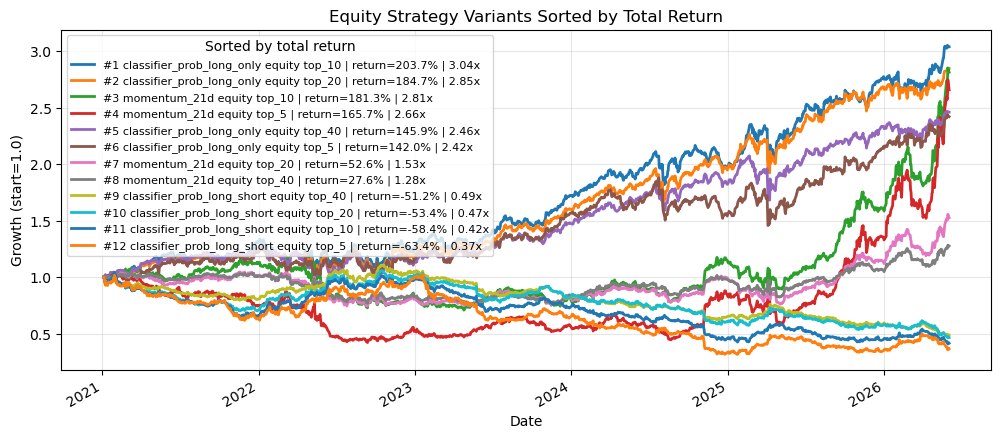

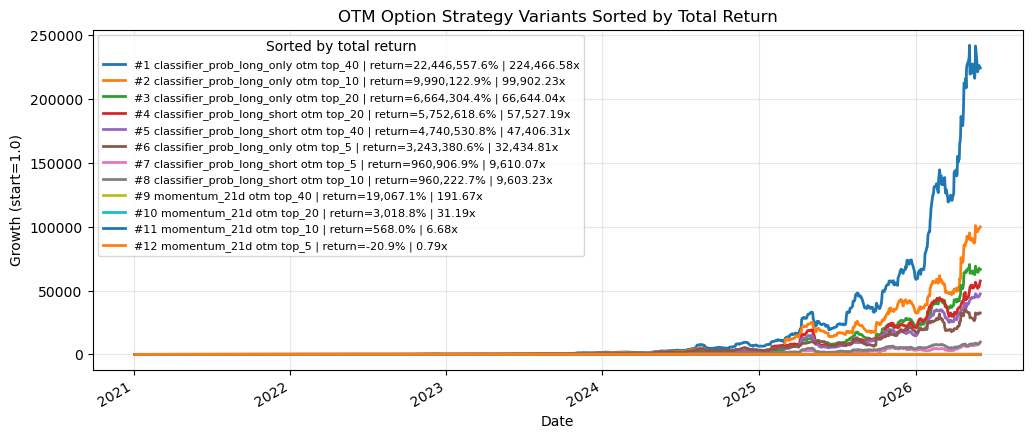

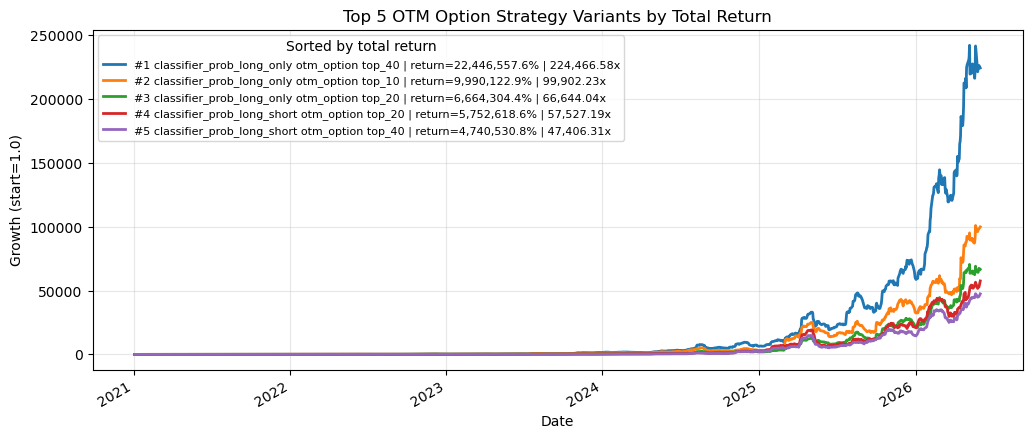

In [8]:
import numpy as np
import matplotlib.pyplot as plt

INSTRUMENT_NAMES = ["equity", "atm_option", "otm_option", "ditm_option"]
ML_STRATEGY_NAMES = ["classifier_prob_long_only", "classifier_prob_long_short"]


def get_growth_multiple(key):
    """
    Returns final growth multiple for a variant key:
    1.0 = flat
    2.0 = +100%
    0.5 = -50%
    """
    if key not in variant_runs:
        return float("-inf")

    eq = variant_runs[key]["summary"]["equity_curve"]

    if eq is None or len(eq) == 0:
        return float("-inf")

    base = max(float(eq.iloc[0]), 1e-12)
    final = float(eq.iloc[-1])

    return final / base


def get_total_return_pct(key):
    growth = get_growth_multiple(key)

    if not np.isfinite(growth):
        return float("-inf")

    return (growth - 1.0) * 100.0


def sort_keys_by_total_return(keys, reverse=True):
    return sorted(keys, key=get_total_return_pct, reverse=reverse)


def plot_variant_curves(
    variant_keys,
    *,
    title,
    label_fn=None,
    figsize=(12, 5),
    top_n=None,
):
    sorted_keys = sort_keys_by_total_return(variant_keys)

    if top_n is not None:
        sorted_keys = sorted_keys[:top_n]

    fig, ax = plt.subplots(figsize=figsize)
    plotted = 0

    for rank, key in enumerate(sorted_keys, start=1):
        if key not in variant_runs:
            continue

        eq = variant_runs[key]["summary"]["equity_curve"]

        if eq is None or len(eq) == 0:
            continue

        base = max(float(eq.iloc[0]), 1e-12)
        growth_curve = eq / base

        total_return_pct = get_total_return_pct(key)
        growth_multiple = get_growth_multiple(key)

        if label_fn is None:
            label = (
                f"#{rank} {key[0]} {key[1]} top_{key[2]} "
                f"| return={total_return_pct:,.1f}% "
                f"| {growth_multiple:,.2f}x"
            )
        else:
            label = label_fn(key, rank, total_return_pct, growth_multiple)

        growth_curve.plot(ax=ax, lw=2, label=label)
        plotted += 1

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Growth (start=1.0)")
    ax.grid(True, alpha=0.3)

    if plotted:
        ax.legend(title="Sorted by total return", fontsize=8)

    plt.show()


strategy_names = sorted(summary_df["strategy"].dropna().unique())
top_k_values = sorted(int(x) for x in summary_df["top_k"].dropna().unique())


# =========================
# Equity variants
# =========================

equity_keys = [
    (strategy_name, "equity", top_k)
    for strategy_name in strategy_names
    for top_k in top_k_values
]

plot_variant_curves(
    equity_keys,
    title="Equity Strategy Variants Sorted by Total Return",
    label_fn=lambda key, rank, ret, growth: (
        f"#{rank} {key[0]} equity top_{key[2]} "
        f"| return={ret:,.1f}% | {growth:,.2f}x"
    ),
)


# =========================
# OTM option variants
# =========================

otm_keys = [
    (strategy_name, "otm_option", top_k)
    for strategy_name in strategy_names
    for top_k in top_k_values
]

plot_variant_curves(
    otm_keys,
    title="OTM Option Strategy Variants Sorted by Total Return",
    label_fn=lambda key, rank, ret, growth: (
        f"#{rank} {key[0]} otm top_{key[2]} "
        f"| return={ret:,.1f}% | {growth:,.2f}x"
    ),
)


# =========================
# Optional: plot only top 5
# =========================

plot_variant_curves(
    otm_keys,
    title="Top 5 OTM Option Strategy Variants by Total Return",
    top_n=5,
)